In [2]:
import warnings                                  # `do not disturbe` mode
warnings.filterwarnings('ignore')

import numpy as np                               # vectors and matrices
import pandas as pd                              # tables and data manipulations
import matplotlib.pyplot as plt                  # plots
import seaborn as sns                            # more plots
import statsmodels.formula.api as smf            # statistics and econometrics
import statsmodels.tsa.api as smt
import statsmodels.api as sm
import scipy.stats as scs

from dateutil.relativedelta import relativedelta # working with dates with style
from scipy.optimize import minimize              # for function minimization
from itertools import product                    # some useful functions
from tqdm import tqdm_notebook
from sklearn.metrics import r2_score, median_absolute_error, mean_absolute_error, mean_squared_log_error
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
from sklearn.model_selection import cross_val_score, TimeSeriesSplit # you have everything done for you
from sklearn.preprocessing import StandardScaler

import plotly.express as px
import plotly.graph_objects as go

import cvxopt
from cvxopt import matrix, solvers
solvers.options['show_progress'] = False

import nbconvert

In [3]:
# for time-series cross-validation set 5 folds 
tscv = TimeSeriesSplit(n_splits=5)

In [4]:
def mean_absolute_percentage_error(y_true, y_pred): 
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


def plotMovingAverage(series, window, plot_intervals=False, scale=1.96, plot_anomalies=False):

    """
        series - dataframe with timeseries
        window - rolling window size 
        plot_intervals - show confidence intervals
        plot_anomalies - show anomalies 

    """
    rolling_mean = series.rolling(window=window).mean()

    plt.figure(figsize=(15,5))
    plt.title("Moving average\n window size = {}".format(window))
    plt.plot(rolling_mean, "g", label="Rolling mean trend")

    # Plot confidence intervals for smoothed values
    if plot_intervals:
        mae = mean_absolute_error(series[window:], rolling_mean[window:])
        deviation = np.std(series[window:] - rolling_mean[window:])
        lower_bond = rolling_mean - (mae + scale * deviation)
        upper_bond = rolling_mean + (mae + scale * deviation)
        plt.plot(upper_bond, "r--", label="Upper Bond / Lower Bond")
        plt.plot(lower_bond, "r--")
        
        # Having the intervals, find abnormal values
        if plot_anomalies:
            anomalies = pd.DataFrame(index=series.index, columns=series.columns)
            anomalies[series<lower_bond] = series[series<lower_bond]
            anomalies[series>upper_bond] = series[series>upper_bond]
            plt.plot(anomalies, "ro", markersize=10)
        
    plt.plot(series[window:], label="Actual values")
    plt.legend(loc="upper left")
    plt.grid(True)

def moving_average(series, n):
    """
        Calculate average of last n observations
    """
    return np.average(series[-n:])

def weighted_average(series, weights):
    """
        Calculate weighter average on series
    """
    result = 0.0
    weights.reverse()
    for n in range(len(weights)):
        result += series.iloc[-n-1] * weights[n]
    return float(result)

def tsplot(y, lags=None, figsize=(12, 7), style='bmh'):
    """
        Plot time series, its ACF and PACF, calculate Dickey–Fuller test
        
        y - timeseries
        lags - how many lags to include in ACF, PACF calculation
    """
    if not isinstance(y, pd.Series):
        y = pd.Series(y)
        
    with plt.style.context(style):    
        fig = plt.figure(figsize=figsize)
        layout = (2, 2)
        ts_ax = plt.subplot2grid(layout, (0, 0), colspan=2)
        acf_ax = plt.subplot2grid(layout, (1, 0))
        pacf_ax = plt.subplot2grid(layout, (1, 1))
        
        y.plot(ax=ts_ax)
        p_value = sm.tsa.stattools.adfuller(y)[1]
        ts_ax.set_title('Time Series Analysis Plots\n Dickey-Fuller: p={0:.5f}'.format(p_value))
        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax)
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax)
        plt.tight_layout()    


def timeseries_train_test_split(X, y, test_size):
    """
        Perform train-test split with respect to time series structure
    """
    
    # get the index after which test set starts
    test_index = int(len(X)*(1-test_size))
    
    X_train = X.iloc[:test_index]
    y_train = y.iloc[:test_index]
    X_test = X.iloc[test_index:]
    y_test = y.iloc[test_index:]
    
    return X_train, X_test, y_train, y_test

def plotModelResults(model, X_train, y_train, X_test, y_test, plot_intervals=False, plot_anomalies=False):
    """
        Plots modelled vs fact values, prediction intervals and anomalies
    
    """
    
    prediction = model.predict(X_test)
    
    plt.figure(figsize=(15, 7))
    plt.plot(prediction, "g", label="prediction", linewidth=2.0)
    plt.plot(y_test.values, label="actual", linewidth=2.0)
    
    if plot_intervals:
        cv = cross_val_score(model, X_train, y_train, 
                                    cv=tscv, 
                                    scoring="neg_mean_absolute_error")
        mae = cv.mean() * (-1)
        deviation = cv.std()
        
        scale = 1.96
        lower = prediction - (mae + scale * deviation)
        upper = prediction + (mae + scale * deviation)
        
        plt.plot(lower, "r--", label="upper bond / lower bond", alpha=0.5)
        plt.plot(upper, "r--", alpha=0.5)
        
        if plot_anomalies:
            anomalies = np.array([np.NaN]*len(y_test))
            anomalies[y_test<lower] = y_test[y_test<lower]
            anomalies[y_test>upper] = y_test[y_test>upper]
            plt.plot(anomalies, "o", markersize=10, label = "Anomalies")
    
    error = mean_absolute_percentage_error(prediction, y_test)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.grid(True);
    
def plotCoefficients(model, X_train):
    """
        Plots sorted coefficient values of the model
    """
    
    coefs = pd.DataFrame(model.coef_, X_train.columns)
    coefs.columns = ["coef"]
    coefs["abs"] = coefs.coef.apply(np.abs)
    coefs = coefs.sort_values(by="abs", ascending=False).drop(["abs"], axis=1)
    
    plt.figure(figsize=(15, 7))
    coefs.coef.plot(kind='bar')
    plt.grid(True, axis='y')
    plt.hlines(y=0, xmin=0, xmax=len(coefs), linestyles='dashed');
    
def prepareData(series, lag_start, lag_end, test_size):
    """
        series: pd.DataFrame
            dataframe with timeseries

        lag_start: int
            initial step back in time to slice target variable 
            example - lag_start = 1 means that the model 
                      will see yesterday's values to predict today

        lag_end: int
            final step back in time to slice target variable
            example - lag_end = 4 means that the model 
                      will see up to 4 days back in time to predict today

        test_size: float
            size of the test dataset after train/test split as percentage of dataset
        
    """
    
    # copy of the initial dataset
    data = pd.DataFrame(series.copy())
    data.columns = ["y"]
    
    # lags of series
    for i in range(lag_start, lag_end):
        data["lag_{}".format(i)] = data.y.shift(i)
    
    # train-test split
    y = data.dropna().y
    X = data.dropna().drop(['y'], axis=1)
    X_train, X_test, y_train, y_test = timeseries_train_test_split(X, y, test_size=test_size)

    return X_train, X_test, y_train, y_test

def runLassoCVonManager(data, y_col, test_size):  
    tscv = TimeSeriesSplit(n_splits=5)
    # train-test split
    y = data.dropna()[y_col]
    X = data.dropna().drop([y_col], axis=1)
    X_train, X_test, y_train, y_test = timeseries_train_test_split(X, y, test_size=test_size)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    lasso = LassoCV(alphas = [0,.001,.01,.1,.5,1,5,10], cv=tscv)
    lasso.fit(X_train_scaled, y_train)
    plotModelResults(lasso, 
                     X_train_scaled, y_train, 
                     X_test_scaled, y_test,
                     plot_intervals=True, plot_anomalies=True)
    plotCoefficients(lasso, X)
    
    return lasso

def runRidgeCVonManager(data, y_col, test_size):  
    tscv = TimeSeriesSplit(n_splits=5)
    # train-test split
    y = data.dropna()[y_col]
    X = data.dropna().drop([y_col], axis=1)
    X_train, X_test, y_train, y_test = timeseries_train_test_split(X, y, test_size=test_size)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    ridge = RidgeCV(alphas = [0,.001,.01,.1,.5,1,5,10], cv=tscv)
    ridge.fit(X_train_scaled, y_train)
    plotModelResults(ridge, 
                     X_train_scaled, y_train, 
                     X_test_scaled, y_test,
                     plot_intervals=True, plot_anomalies=True)
    plotCoefficients(ridge, X)
    
    return ridge

%matplotlib inline

In [5]:
import yfinance as yf

# List of ISINs (for demonstration, using tickers instead of ISINs)
tickers = ['JSFRX', 
           'ATSX.TO', 
           'PWLEX', 
           '0P0001N58O', 
           '0P0000F8IZ.F',
           '0P00018E88',
           '0P0000UF8Z',
           '0P0001A9KH',
           'JUEMX',
           '0P0001E1Y3',
           '0P0001KGO9',
           '0P00000IHO.L',
           '0P0000VNQE',
           'FRNRX',
           'VIPSX',
           '0P00018LTL',
           '0P0001BT7G',
           'PTHYX',
           'VWETX',
           '0P0001IQQZ.L']

# Define the start and end dates
#end date equal to the 30th NOvember 2024
end_date ='2024-11-30'
start_date = '2021-11-30'

JHancock Seaport Long/Short
DNB Fund TMT L/S Equities
PIMCO RAE Worldwide Long/Short PLUS

Lyxor Epsilon Global Trend Fund
Winton Trend UCITS

Algebris Global Crdt Opps   
Dynamic Total Return Bond Fund

Pentaris Bares US Equity Fund
Voya US Stock Index Fund
BlackRock Sust Advtg US Eq A USD Acc

Waverton European Capital Growth Fund
MM Access European Equities Fund

Nomura Fds Japan Strategic Value Fund

Franklin Natural Resources Fund
Vanguard Inflation-Protected Secs Inv 

Fubon Global REIT Fund 

Mercer Global High Yield Bd M1 USD
Putnam Tax-Free High Yield B

CI Global Investment Grade Class IH
Muzinich Glbl Shrt DurInvmtGrdHGBPAccH 


In [6]:
# Fetch the adjusted close price data
data = yf.download(tickers, start=start_date, end=end_date,interval='1mo')['Adj Close']

# Calculate the monthly returns

[*********************100%***********************]  20 of 20 completed


In [7]:
print(data.head())

Ticker                     0P00000IHO.L  0P0000F8IZ.F  0P0000UF8Z  0P0000VNQE  \
Date                                                                            
2021-12-01 00:00:00+00:00      3.624075    146.320007     11.2792  195.929703   
2022-01-01 00:00:00+00:00      3.664920    131.679993     10.9453  193.340103   
2022-02-01 00:00:00+00:00      3.366702    129.449997     10.8447  193.568604   
2022-03-01 00:00:00+00:00      3.498464    139.199997     10.5347  191.865295   
2022-04-01 00:00:00+00:00      3.447527    129.479996     10.1579  176.653305   

Ticker                     0P00018E88  0P00018LTL  0P0001A9KH  0P0001BT7G  \
Date                                                                        
2021-12-01 00:00:00+00:00  148.940002      0.3409  219.953156  125.349998   
2022-01-01 00:00:00+00:00  147.369995      0.3173  187.355988  121.690002   
2022-02-01 00:00:00+00:00  146.270004      0.3173  176.440186  120.180000   
2022-03-01 00:00:00+00:00  145.539993      0.32

In [8]:
monthly_returns = data.pct_change().dropna()
data = monthly_returns

In [9]:
print(data.head())

Ticker                     0P00000IHO.L  0P0000F8IZ.F  0P0000UF8Z  0P0000VNQE  \
Date                                                                            
2022-01-01 00:00:00+00:00      0.011271     -0.100055   -0.029603   -0.013217   
2022-02-01 00:00:00+00:00     -0.081371     -0.016935   -0.009191    0.001182   
2022-03-01 00:00:00+00:00      0.039137      0.075319   -0.028585   -0.008800   
2022-04-01 00:00:00+00:00     -0.014560     -0.069828   -0.035768   -0.079285   
2022-05-01 00:00:00+00:00      0.048729     -0.033441   -0.001575    0.029923   

Ticker                     0P00018E88  0P00018LTL  0P0001A9KH  0P0001BT7G  \
Date                                                                        
2022-01-01 00:00:00+00:00   -0.010541   -0.069229   -0.148201   -0.029198   
2022-02-01 00:00:00+00:00   -0.007464    0.000000   -0.058262   -0.012409   
2022-03-01 00:00:00+00:00   -0.004991    0.022376   -0.035160   -0.011233   
2022-04-01 00:00:00+00:00   -0.006527   -0.0557

In [10]:
interesting_cols = data.columns
returns = data.sort_index().dropna()

In [11]:
print(data)

Ticker                     0P00000IHO.L  0P0000F8IZ.F  0P0000UF8Z  0P0000VNQE  \
Date                                                                            
2022-01-01 00:00:00+00:00      0.011271     -0.100055   -0.029603   -0.013217   
2022-02-01 00:00:00+00:00     -0.081371     -0.016935   -0.009191    0.001182   
2022-03-01 00:00:00+00:00      0.039137      0.075319   -0.028585   -0.008800   
2022-04-01 00:00:00+00:00     -0.014560     -0.069828   -0.035768   -0.079285   
2022-05-01 00:00:00+00:00      0.048729     -0.033441   -0.001575    0.029923   
2022-06-01 00:00:00+00:00     -0.122515     -0.110028   -0.026405   -0.081219   
2022-07-01 00:00:00+00:00      0.011844      0.116987    0.041168    0.034149   
2022-08-01 00:00:00+00:00      0.010239      0.017442   -0.031039   -0.015868   
2022-09-01 00:00:00+00:00     -0.037162     -0.119608   -0.005913   -0.088739   
2022-10-01 00:00:00+00:00      0.085842      0.104810   -0.011936    0.015752   
2022-11-01 00:00:00+00:00   

In [12]:
#calculate mean monthly return and covariance of monthly returns
mean_monthly_returns = returns.mean()
cov_matrix = returns.cov()
#set number of runs of random portfolio weights
num_portfolios = 25000

print(cov_matrix)


Ticker        0P00000IHO.L  0P0000F8IZ.F  0P0000UF8Z  0P0000VNQE  0P00018E88  \
Ticker                                                                         
0P00000IHO.L      0.001745      0.001309    0.000154    0.000995    0.000564   
0P0000F8IZ.F      0.001309      0.003284    0.000699    0.001658    0.000864   
0P0000UF8Z        0.000154      0.000699    0.000440    0.000618    0.000267   
0P0000VNQE        0.000995      0.001658    0.000618    0.002028    0.000694   
0P00018E88        0.000564      0.000864    0.000267    0.000694    0.000397   
0P00018LTL        0.001029      0.002418    0.000848    0.001820    0.000922   
0P0001A9KH        0.001934      0.004617    0.001459    0.003367    0.001442   
0P0001BT7G        0.000643      0.001283    0.000458    0.000998    0.000478   
0P0001E1Y3        0.001004      0.002467    0.000681    0.001550    0.000692   
0P0001IQQZ.L      0.000166      0.000213    0.000099    0.000204    0.000110   
0P0001KGO9        0.001570      0.002199

In [13]:
print (interesting_cols)

Index(['0P00000IHO.L', '0P0000F8IZ.F', '0P0000UF8Z', '0P0000VNQE',
       '0P00018E88', '0P00018LTL', '0P0001A9KH', '0P0001BT7G', '0P0001E1Y3',
       '0P0001IQQZ.L', '0P0001KGO9', '0P0001N58O', 'ATSX.TO', 'FRNRX', 'JSFRX',
       'JUEMX', 'PTHYX', 'PWLEX', 'VIPSX', 'VWETX'],
      dtype='object', name='Ticker')


In [14]:
#set up array to hold results
#We have increased the size of the array to hold the weight values for each stock
results = np.zeros((3+len(interesting_cols),num_portfolios))

In [15]:
for i in range(num_portfolios):
    #select random weights for portfolio holdings
    weights = np.array(np.random.random(len(interesting_cols)))
    
    #rebalance weights to sum to 1
    weights /= np.sum(weights)
    
    #calculate portfolio return and volatility
    portfolio_return = np.sum(mean_monthly_returns * weights) * 12
    portfolio_std_dev = np.sqrt(np.dot(weights.T,np.dot(cov_matrix, weights))) * np.sqrt(12)
    
    #store results in results array
    results[0,i] = portfolio_return
    results[1,i] = portfolio_std_dev
    #store Sharpe Ratio (return / volatility) - risk free rate element excluded for simplicity
    results[2,i] = results[0,i] / results[1,i]
    #iterate through the weight vector and add data to results array
    for j in range(len(weights)):
        results[j+3,i] = weights[j]

cols = ['ret','stdev','sharpe']
cols.extend(interesting_cols.tolist())
#convert results array to Pandas DataFrame
results_frame = pd.DataFrame(results.T,columns=cols)

#locate position of portfolio with highest Sharpe Ratio
max_sharpe_port = results_frame.iloc[results_frame['sharpe'].idxmax()]
#locate positon of portfolio with minimum standard deviation
min_vol_port = results_frame.iloc[results_frame['stdev'].idxmin()]

In [16]:
print(results_frame.head())

        ret     stdev    sharpe  0P00000IHO.L  0P0000F8IZ.F  0P0000UF8Z  \
0  0.048294  0.094870  0.509056      0.053963      0.017311    0.091615   
1  0.067742  0.086625  0.782011      0.071271      0.068717    0.063078   
2  0.048978  0.105744  0.463172      0.032891      0.049230    0.034824   
3  0.065643  0.109654  0.598635      0.029780      0.057756    0.007382   
4  0.059495  0.094474  0.629750      0.043524      0.035368    0.083812   

   0P0000VNQE  0P00018E88  0P00018LTL  0P0001A9KH  ...  0P0001KGO9  \
0    0.038379    0.080102    0.100048    0.021266  ...    0.047946   
1    0.002831    0.057705    0.008467    0.007364  ...    0.025665   
2    0.047481    0.065783    0.082132    0.058088  ...    0.032923   
3    0.013171    0.033287    0.095973    0.004019  ...    0.046176   
4    0.055645    0.070472    0.021642    0.030393  ...    0.006469   

   0P0001N58O   ATSX.TO     FRNRX     JSFRX     JUEMX     PTHYX     PWLEX  \
0    0.093438  0.053243  0.016968  0.093188  0.0406

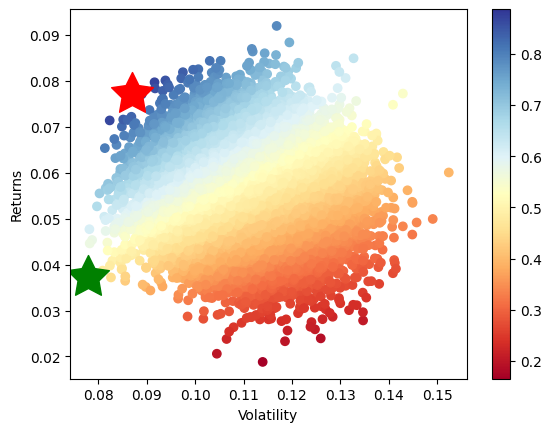

In [17]:
#create scatter plot coloured by Sharpe Ratio
plt.scatter(results_frame.stdev,results_frame.ret,c=results_frame.sharpe,cmap='RdYlBu')
plt.xlabel('Volatility')
plt.ylabel('Returns')
plt.colorbar()
#plot red star to highlight position of portfolio with highest Sharpe Ratio
plt.scatter(max_sharpe_port[1],max_sharpe_port[0],marker=(5,1,0),color='r',s=1000)
#plot green star to highlight position of minimum variance portfolio
plt.scatter(min_vol_port[1],min_vol_port[0],marker=(5,1,0),color='g',s=1000)

In [18]:
#Solve for the mean-variance optimized portfolio using quadratic programming and cvxopt

#calculate mean monthly return and covariance of monthly returnsmean_monthly_returns = returns.mean()
mean_monthly_returns = np.array(data.mean(axis=0))
cov_matrix = data.cov()

numcols = data.shape[1]

#set number of returns to minimize variance for
num_portfolios = 10000

max_return = max(mean_monthly_returns)
min_return = min(mean_monthly_returns)

return_vec = np.arange(min_return,max_return,(max_return-min_return)/num_portfolios)

#set up array to hold results
#We have increased the size of the array to hold the weight values for each stock
results = np.zeros((3+numcols,num_portfolios))

for i in range(num_portfolios):
    
    #get current return target
    r = return_vec[i]
    
    #set up values to put into solver
    P = matrix(np.array((cov_matrix)))
    q = matrix(np.zeros([numcols,1]))
    G = matrix(-np.identity(numcols))
    h = matrix(np.zeros([numcols,1]))
    A = matrix(np.vstack((np.ones([1,numcols]),matrix(mean_monthly_returns).T)))
    b = matrix([[1.0,r]])
    
    #use cvxopt to solve for minimum variance at given return level
    weights = solvers.qp(P,q,G,h,A,b)['x']

    #calculate portfolio return and volatility
    portfolio_return = np.sum(mean_monthly_returns * weights.T) * 12
    portfolio_std_dev = np.sqrt(weights.T*P*weights) * np.sqrt(12)

    #store results in results array
    results[0,i] = portfolio_return
    results[1,i] = portfolio_std_dev
    #store Sharpe Ratio (return / volatility) - risk free rate element excluded for simplicity
    results[2,i] = results[0,i] / results[1,i]
    #iterate through the weight vector and add data to results array
    for j in range(len(weights)):
        results[j+3,i] = weights[j]

cols = ['ret','stdev','sharpe']
#addcols = interesting_cols.tolist()
#cols.extend(addcols[0:])
cols.extend(data.columns.tolist())

#convert results array to Pandas DataFrame
results_frame = pd.DataFrame(results.T,columns=cols)

#locate position of portfolio with highest Sharpe Ratio
max_sharpe_port = results_frame.iloc[results_frame['sharpe'].idxmax()]
#locate positon of portfolio with minimum standard deviation
min_vol_port = results_frame.iloc[results_frame['stdev'].idxmin()]


0.04090419606185748 0.025397160615273275


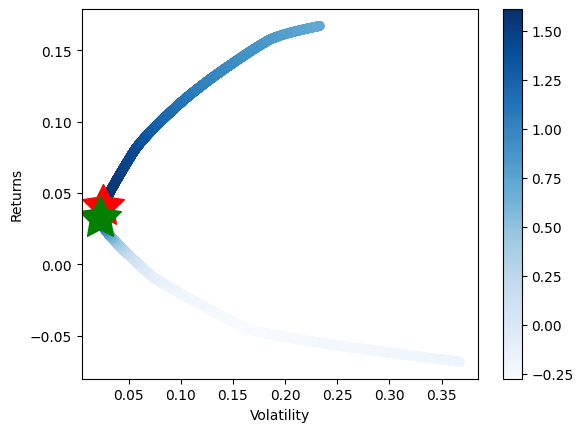

In [19]:
#create scatter plot coloured by Sharpe Ratio
plt.scatter(results_frame.stdev,results_frame.ret,c=results_frame.sharpe,cmap='Blues')
plt.xlabel('Volatility')
plt.ylabel('Returns')
plt.colorbar()
#plot red star to highlight position of portfolio with highest Sharpe Ratio
plt.scatter(max_sharpe_port[1],max_sharpe_port[0],marker=(5,1,0),color='r',s=1000)
#plot green star to highlight position of minimum variance portfolio
plt.scatter(min_vol_port[1],min_vol_port[0],marker=(5,1,0),color='g',s=1000)
print(max_sharpe_port[0],max_sharpe_port[1])

As the QP gives a better portfolio lets use that to create proforma returns and then predict them in future.

In [20]:
WeightedReturns = returns.mul( max_sharpe_port[3:], axis =1 )
WeightedReturns.sum(axis=1)
returns['Portfolio'] = WeightedReturns.sum(axis=1)

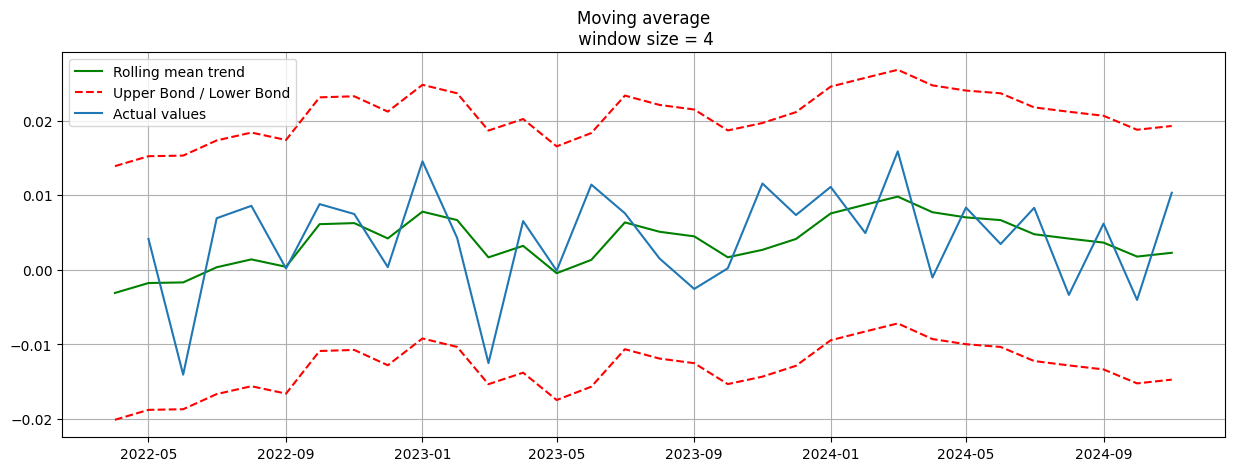

In [21]:
plotMovingAverage(returns['Portfolio'], 4, plot_intervals=True)


If we would have invested in this portfolio, the total return till now would be like this

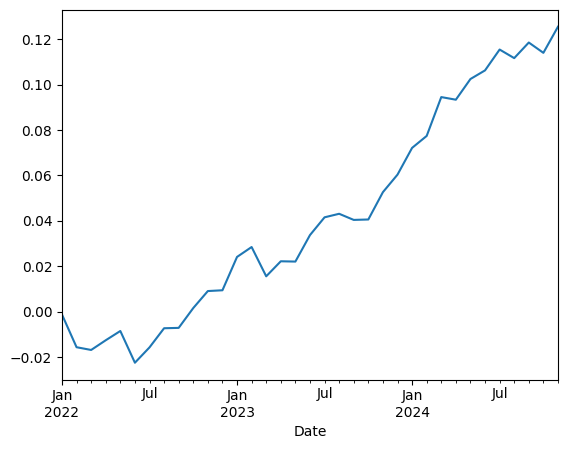

In [22]:
# Plot the cumulative portfolio returns over time
CumulativeReturns = ((1+returns["Portfolio"]).cumprod()-1)
CumulativeReturns.plot()
plt.show()

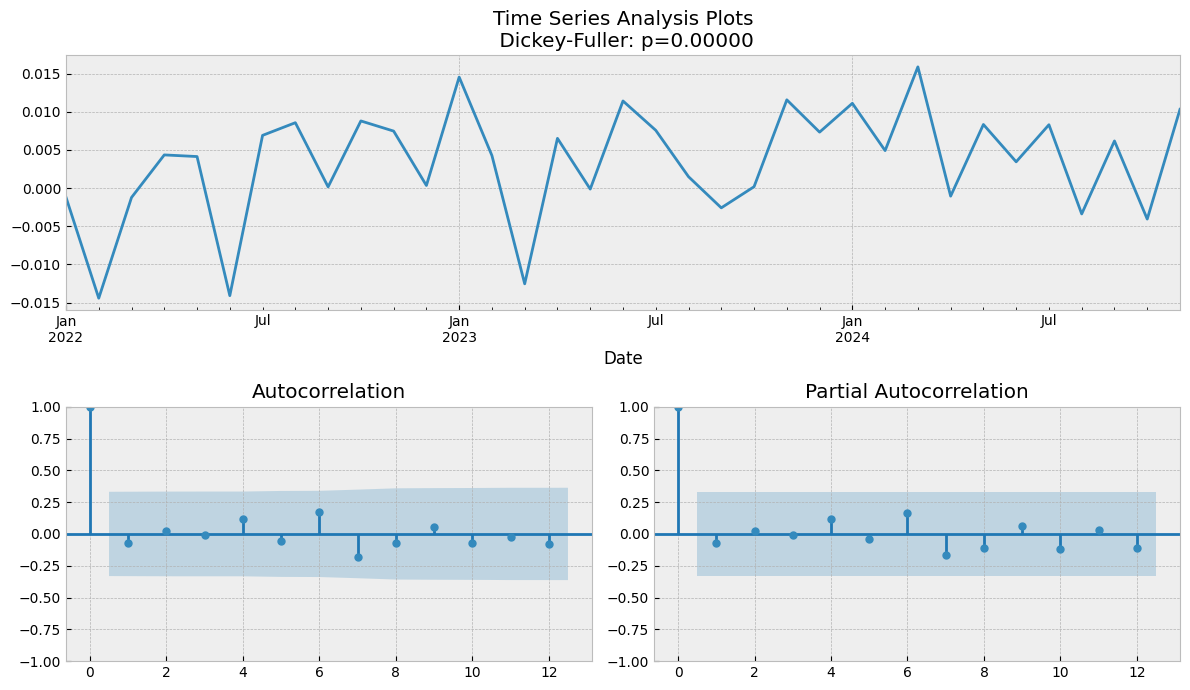

In [23]:
tsplot( returns["Portfolio"], lags=12)

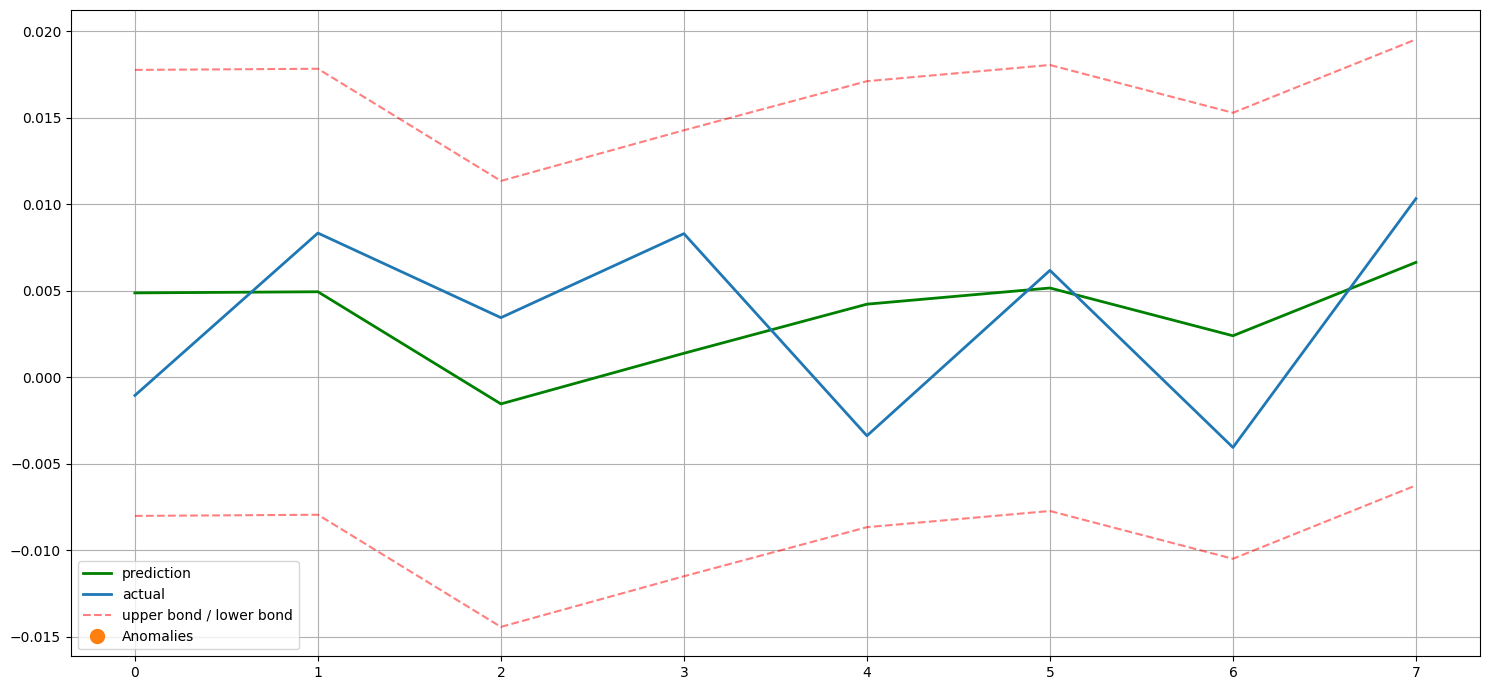

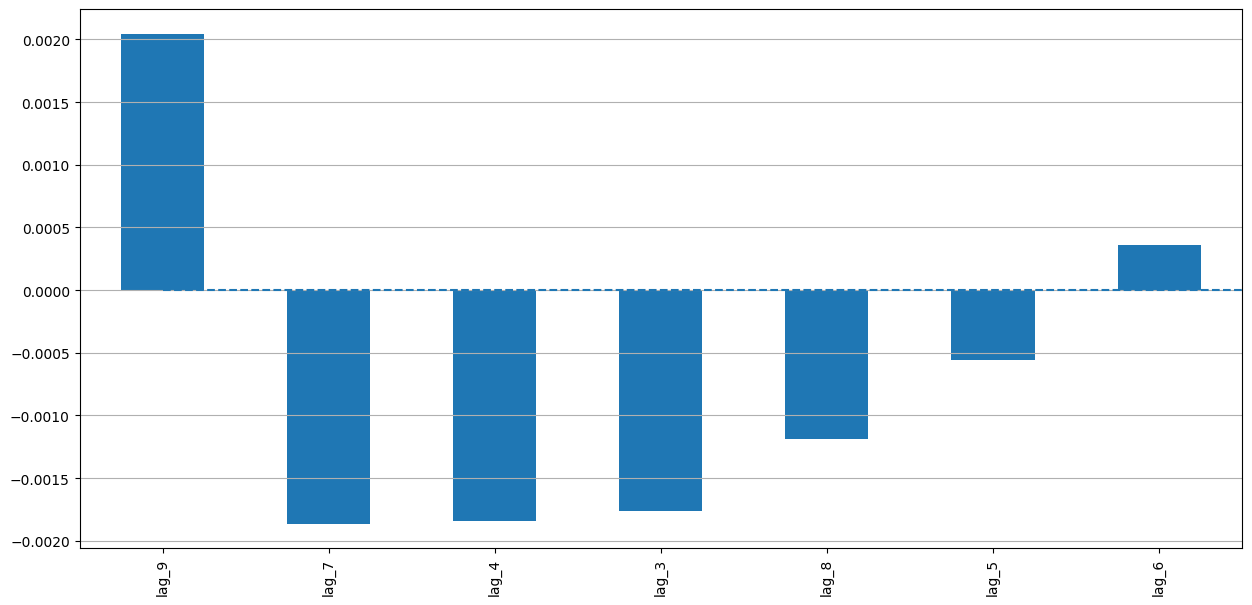

In [24]:
X_train, X_test, y_train, y_test = prepareData(returns["Portfolio"], lag_start=3, lag_end=10, test_size=0.3)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

plotModelResults(lr, X_train_scaled, y_train, X_test_scaled, y_test, plot_intervals=True, plot_anomalies=True)
plotCoefficients(lr, X_train)

Before using Time Series forecasting lets see if the lags are correlated, and if we have to adjust for autocorrelation

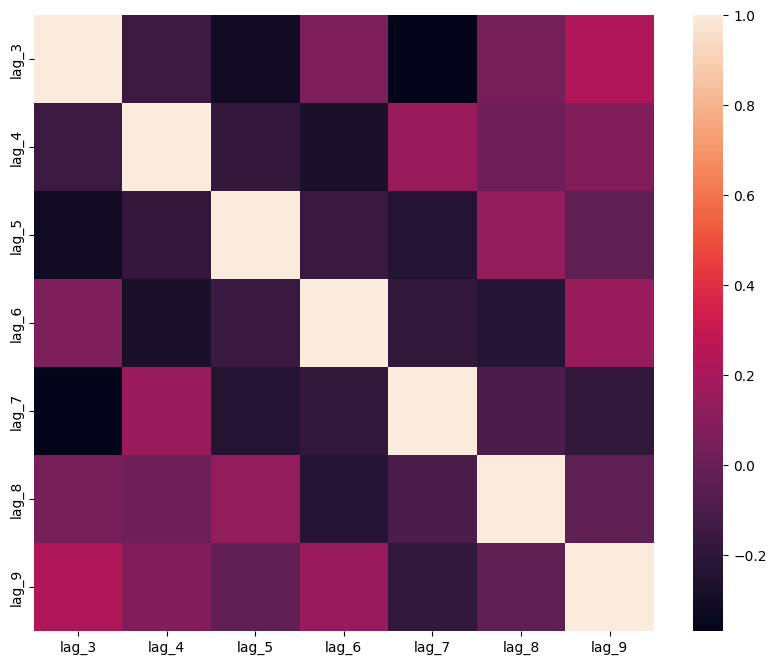

In [25]:
#before using Time Series forecasting lets see if the lags are correlated
plt.figure(figsize=(10, 8))
sns.heatmap(X_train.corr());

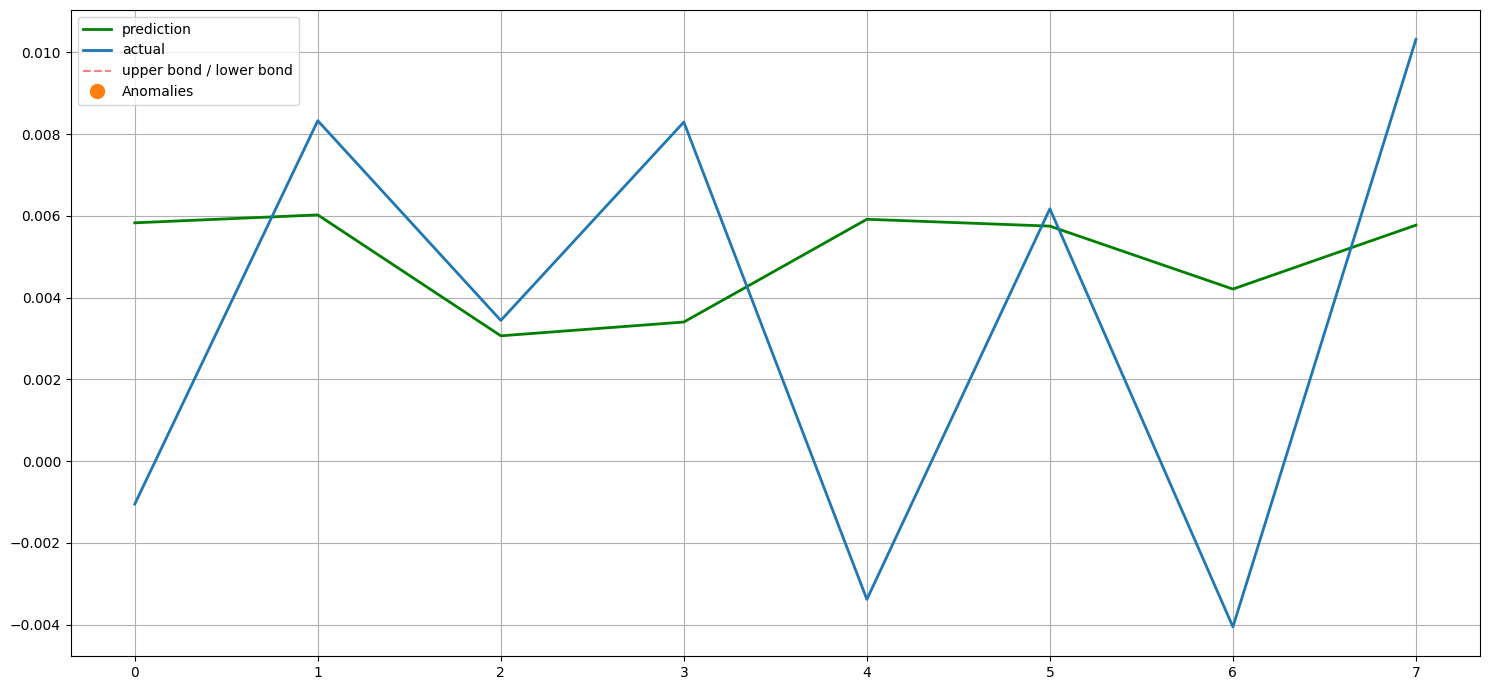

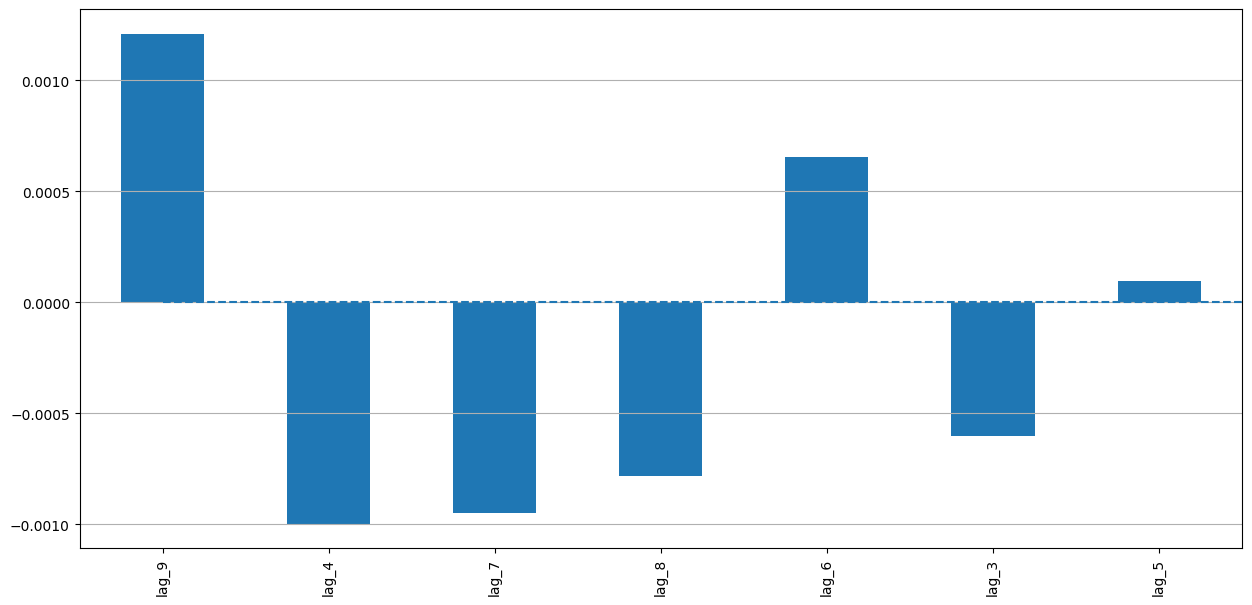

In [26]:
from sklearn.linear_model import LassoCV, RidgeCV

ridge = RidgeCV(cv=tscv)
ridge.fit(X_train_scaled, y_train)

plotModelResults(ridge, 
                 X_train_scaled, y_train,
                 X_test_scaled, y_test,
                 plot_intervals=True, plot_anomalies=True)
plotCoefficients(ridge, X_train)

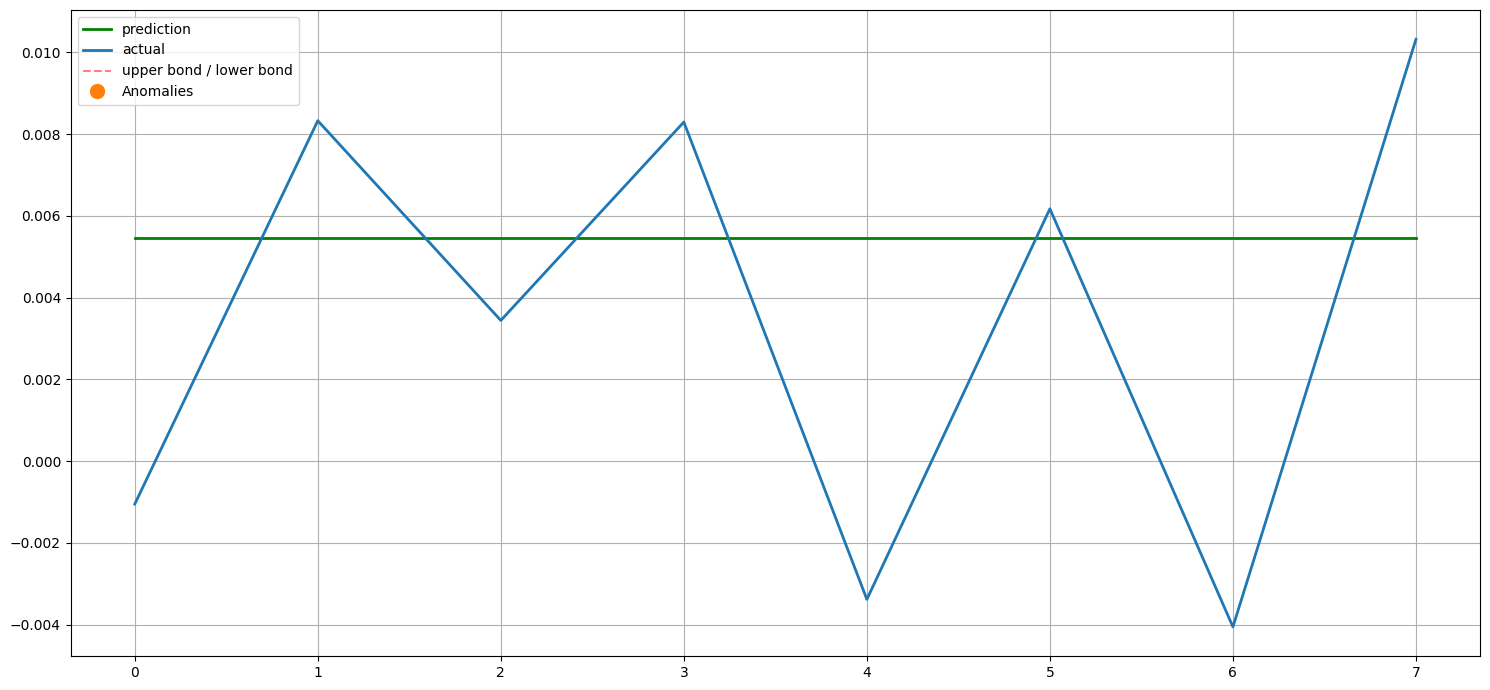

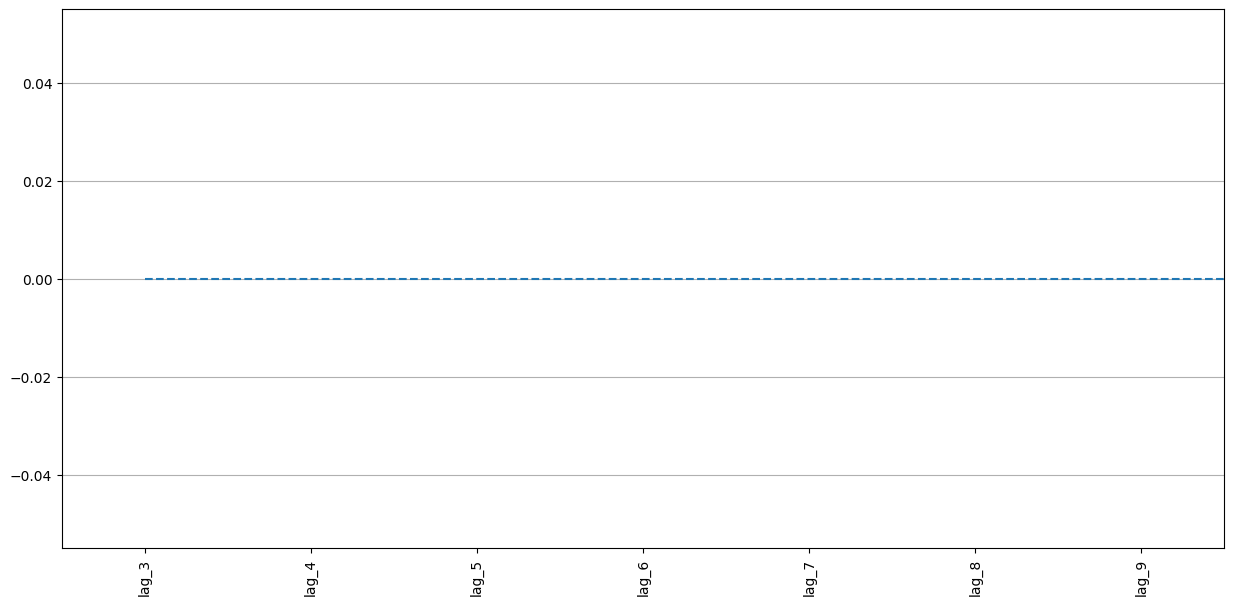

In [27]:
lasso = LassoCV(cv=tscv, alphas = [0,.001,.01,.1,.5,1,5,10] )
lasso.fit(X_train_scaled, y_train)

plotModelResults(lasso, 
                 X_train_scaled, y_train,
                 X_test_scaled, y_test,
                 plot_intervals=True, plot_anomalies=True)
plotCoefficients(lasso, X_train)

As we can see above, Lasso unfortunately doesnt converge for such a small dataset.

In [28]:
#now lets train using SARIMA
# setting initial values and some bounds for them
ps = range(2, 5)
d=1 
qs = range(2, 5)
Ps = range(0, 2)
D=1 
Qs = range(0, 2)
s = 24 # season length is still 24

# creating list with all the possible combinations of parameters
parameters = product(ps, qs, Ps, Qs)
parameters_list = list(parameters)
len(parameters_list)

36

In [29]:
from tqdm.notebook import tqdm
import statsmodels.api as sm

def optimizeSARIMA(ret, parameters_list, d, D, s):
    results = []
    best_aic = float("inf")

    for param in tqdm(parameters_list):
        # we need try-except because on some combinations model fails to converge
        try:
            model = sm.tsa.statespace.SARIMAX(ret, order=(param[0], d, param[1]), 
                                              seasonal_order=(param[2], D, param[3], s)).fit(disp=-1)
            aic = model.aic
            if aic < best_aic:
                best_model = model
                best_aic = aic
            results.append([param, model.aic])
        except:
            continue

    result_table = pd.DataFrame(results, columns=['parameters', 'aic'])
    result_table = result_table.sort_values(by='aic', ascending=True).reset_index(drop=True)
    return result_table

# Example usage

result_table = optimizeSARIMA(returns["Portfolio"], parameters_list, d, D, s)

  0%|          | 0/36 [00:00<?, ?it/s]

/Users/Massimiliano/anaconda3/envs/Environment3_15/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/Massimiliano/anaconda3/envs/Environment3_15/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/Massimiliano/anaconda3/envs/Environment3_15/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/Massimiliano/anaconda3/envs/Environment3_15/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/Ma

In [30]:
import warnings
warnings.filterwarnings('ignore')
result_table = optimizeSARIMA(returns["Portfolio"], parameters_list, d, D, s)

  0%|          | 0/36 [00:00<?, ?it/s]

In [31]:
print(result_table.head())

     parameters        aic
0  (2, 2, 0, 0) -51.530227
1  (2, 3, 0, 0) -50.104475
2  (2, 2, 0, 1) -49.412249
3  (3, 2, 0, 0) -49.248815
4  (2, 4, 0, 0) -48.990184


In [32]:
# set the parameters that give the lowest AIC
p, q, P, Q = result_table.parameters[0]

best_model=sm.tsa.statespace.SARIMAX(returns["Portfolio"], order=(p, d, q), 
                                        seasonal_order=(P, D, Q, s)).fit(disp=-1)
print(best_model.summary())

                                      SARIMAX Results                                      
Dep. Variable:                           Portfolio   No. Observations:                   35
Model:             SARIMAX(2, 1, 2)x(0, 1, [], 24)   Log Likelihood                  30.765
Date:                             Mon, 23 Dec 2024   AIC                            -51.530
Time:                                     22:06:17   BIC                            -50.017
Sample:                                 01-01-2022   HQIC                           -53.190
                                      - 11-01-2024                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2293      1.507     -0.152      0.879      -3.183       2.724
ar.L2         -0.4784      

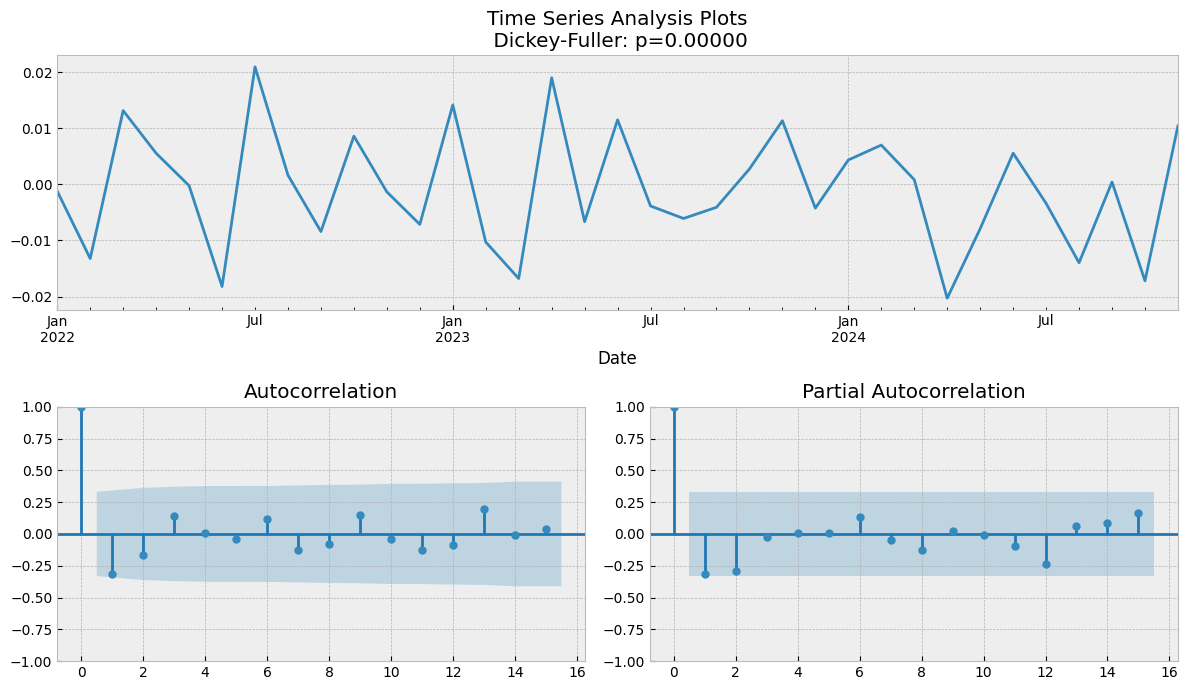

In [33]:
tsplot(best_model.resid, lags=15)

In [34]:
def plotSARIMA(series, model, n_steps):
    """
    Plot the SARIMA model forecast against the actual series.
    
    Parameters:
    series (pd.Series): The original time series data.
    model (SARIMAXResults): The fitted SARIMA model.
    n_steps (int): The number of steps to forecast.
    """
    # Copy the original series
    data = pd.DataFrame(series.copy())
    data.columns = ['original']
    
    # Add the model's fitted values to the DataFrame
    data['arima_model'] = model.fittedvalues
    
    # Shift the fitted values to align with the original series
    s = model.specification.seasonal_periods
    d = model.specification.order[1]
    data['arima_model'] = data['arima_model'].shift(s+d)
    
    # Set the first s+d values to NaN
    data['arima_model'][:s+d] = np.NaN
    
    # Forecast n_steps forward
    forecast = model.get_forecast(steps=n_steps).predicted_mean
    forecast_index = pd.date_range(start=data.index[-1], periods=n_steps+1, inclusive='right')
    forecast = pd.Series(forecast, index=forecast_index)
    
    # Concatenate the forecast with the original series
    forecast = pd.concat([data['arima_model'], forecast])
    
    # Calculate the error
    error = mean_absolute_percentage_error(data['original'][s+d:], data['arima_model'][s+d:])
    
    # Plot the original series and the forecast
    plt.figure(figsize=(12, 6))
    plt.plot(data['original'], label='Original')
    plt.plot(forecast, color='red', label='Forecast')
    plt.title(f'SARIMA Model Forecast\nMAPE: {error:.2f}')
    plt.legend()
    plt.show()


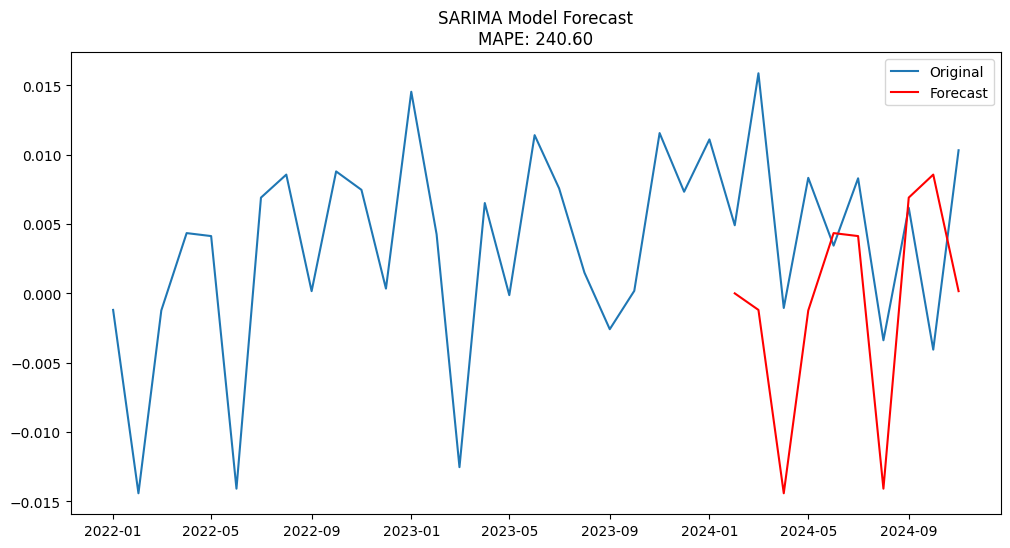

In [35]:
plotSARIMA(returns["Portfolio"], best_model, 12)

In [ ]:
##Create the AQR daily dataset and save it for future use
SMB = pd.read_excel("Betting Against Beta Equity Factors Monthly.xlsx", sheet_name="SMB", index_col=0, usecols=[0,24])
HML = pd.read_excel("Betting Against Beta Equity Factors Monthly.xlsx", sheet_name="HML Devil", index_col=0, usecols=[0, 24])
UMD = pd.read_excel("Betting Against Beta Equity Factors Monthly.xlsx", sheet_name="UMD", index_col=0, usecols=[0, 24])
RF = pd.read_excel("Betting Against Beta Equity Factors Monthly.xlsx", sheet_name="RF", index_col=0)
MKT = pd.read_excel("Betting Against Beta Equity Factors Monthly.xlsx", sheet_name="MKT", index_col=0, usecols=[0, 24])
BAB = pd.read_excel("Betting Against Beta Equity Factors Monthly.xlsx", sheet_name="BAB Factors", index_col=0, usecols=[0, 24])
HML_FF = pd.read_excel("Betting Against Beta Equity Factors Monthly.xlsx", sheet_name="HML FF", index_col=0, usecols=[0, 24])

# Concatenate the DataFrames along the columns
AQR = pd.concat([SMB, HML, UMD, RF, MKT, BAB, HML_FF], axis=1)

# Convert the index to datetime and sort it
AQR.index = pd.to_datetime(AQR.index)
AQR = AQR.sort_index()

# Save the combined DataFrame to a CSV file
AQR.to_csv("AQR_combined.csv", index_label="Date")

# Print the shapes of the DataFrames
print(AQR.shape, HML.shape, SMB.shape, UMD.shape, RF.shape, MKT.shape, BAB.shape, HML_FF.shape)

In [110]:
# Load the data from the Excel file
SMB = pd.read_excel("Betting Against Beta Equity Factors Monthly.xlsx", sheet_name="SMB", index_col=0, usecols=[0,24], skiprows=19)
HML = pd.read_excel("Betting Against Beta Equity Factors Monthly.xlsx", sheet_name="HML Devil", index_col=0, usecols=[0, 24], skiprows=19)
BAB = pd.read_excel("Betting Against Beta Equity Factors Monthly.xlsx", sheet_name="BAB Factors", index_col=0, usecols=[0,24], skiprows=19)
MKT = pd.read_excel("Betting Against Beta Equity Factors Monthly.xlsx", sheet_name="MKT", index_col=0, usecols=[0, 24], skiprows=19)
RF = pd.read_excel("Betting Against Beta Equity Factors Monthly.xlsx", sheet_name="RF", index_col=0, skiprows=19)
UMD = pd.read_excel("Betting Against Beta Equity Factors Monthly.xlsx", sheet_name="UMD", index_col=0, usecols=[0, 24], skiprows=19)
HML_FF = pd.read_excel("Betting Against Beta Equity Factors Monthly.xlsx", sheet_name="HML FF", index_col=0, usecols=[0,24], skiprows=19)


SMB.columns = ['SMB']
HML.columns = ['HML']
UMD.columns = ['UMD']
RF.columns = ['RF']
MKT.columns = ['MKT']
BAB.columns = ['BAB']
HML_FF.columns = ['HML_FF']


In [112]:
# Merge the series into one DataFrame
AQR = pd.concat([SMB, HML, UMD, RF, MKT, BAB, HML_FF],axis=1)

#make the first column as a date index and merge the dataframes
AQR.index = pd.to_datetime(AQR.index)
AQR = AQR.sort_index()


print(AQR.head())

                 SMB       HML  UMD      RF       MKT  BAB    HML_FF
1926-08-31 -0.013958  0.052351  NaN  0.0025  0.026245  NaN  0.054077
1926-09-30 -0.011979 -0.023349  NaN  0.0023  0.003287  NaN -0.005076
1926-10-31  0.005102  0.008253  NaN  0.0032 -0.031103  NaN  0.010814
1926-11-30 -0.012421  0.002025  NaN  0.0031  0.024357  NaN  0.002133
1926-12-31 -0.008416  0.021821  NaN  0.0028  0.025881  NaN  0.011135


In [193]:
bmk_FI = ['USAG.L', 
           'JNK']

end_date ='2024-11-30'
start_date = '2021-11-30'

In [304]:
hyig= yf.download(bmk_FI, start=start_date, end=end_date,interval='1mo')['Adj Close']

[*********************100%***********************]  2 of 2 completed


In [305]:
#rename columns USGAG.L and JNK to US IG  and US HY
hyig.columns = ['US IG', 'US HY']

In [306]:
# Ensure the index of hyig is in datetime format
hyig.index = pd.to_datetime(hyig.index)
# Format the index as yyyy-mm-dd
hyig.index = hyig.index.strftime('%Y-%m-%d')


In [307]:
print(hyig.head())

                US IG       US HY
Date                             
2021-12-01  89.154221  101.665260
2022-01-01  87.314209   99.629662
2022-02-01  86.263824   97.722725
2022-03-01  85.089439   95.871536
2022-04-01  81.341995   92.229095


In [337]:
import pandas_datareader.data as web

series_ids = {
    '1 Month': 'DGS1MO',
    '3 Month': 'DGS3MO',
    '6 Month': 'DGS6MO',
    '1 Year': 'DGS1',
    '2 Year': 'DGS2',
    '3 Year': 'DGS3',
    '5 Year': 'DGS5',
    '7 Year': 'DGS7',
    '10 Year': 'DGS10',
    '20 Year': 'DGS20',
    '30 Year': 'DGS30'
}

# Fetch the data from FRED
yield_curve_data = web.DataReader(list(series_ids.values()), 'fred', start_date, end_date)

# Rename the columns to match the maturities
yield_curve_data.columns = list(series_ids.keys())


In [338]:
# Resample the data to monthly frequency, taking the first observation of each month
curve = yield_curve_data.resample('M').last()

In [339]:
#shift the date index of 1 day
curve.index = curve.index + pd.DateOffset(days=1)

#rename column "DATE" to "Date"
curve.index.names = ['Date']

In [347]:
#make yield curve data a dataframe
curve= pd.DataFrame(curve/100).dropna()

# Ensure the index of curve is in datetime format
curve.index = pd.to_datetime(curve.index)
# Format the index as yyyy-mm-dd
curve.index = curve.index.strftime('%Y-%m-%d')

In [348]:
print(curve.head())

             1 Month   3 Month   6 Month    1 Year    2 Year    3 Year  \
Date                                                                     
2021-12-01  0.000011  0.000005  0.000010  0.000024  0.000052  0.000081   
2022-01-01  0.000006  0.000006  0.000019  0.000039  0.000073  0.000097   
2022-02-01  0.000003  0.000022  0.000049  0.000078  0.000118  0.000139   
2022-03-01  0.000006  0.000035  0.000069  0.000101  0.000144  0.000162   
2022-04-01  0.000017  0.000052  0.000106  0.000163  0.000228  0.000245   

              5 Year    7 Year   10 Year   20 Year   30 Year  
Date                                                          
2021-12-01  0.000114  0.000136  0.000143  0.000185  0.000178  
2022-01-01  0.000126  0.000144  0.000152  0.000194  0.000190  
2022-02-01  0.000162  0.000175  0.000179  0.000217  0.000211  
2022-03-01  0.000171  0.000181  0.000183  0.000225  0.000217  
2022-04-01  0.000242  0.000240  0.000232  0.000259  0.000244  


In [349]:
print(hyig.head())

                US IG       US HY
Date                             
2021-12-01  89.154221  101.665260
2022-01-01  87.314209   99.629662
2022-02-01  86.263824   97.722725
2022-03-01  85.089439   95.871536
2022-04-01  81.341995   92.229095


In [361]:
#use date as index
fi_factors_nonPCA = pd.concat([hyig, curve], axis=1)
fi_factors_nonPCA=fi_factors_nonPCA.dropna().sort_index()

In [362]:
fi_factors_nonPCA.head()

,US IG,US HY,1 Month,3 Month,6 Month,1 Year,2 Year,3 Year,5 Year,7 Year,10 Year,20 Year,30 Year
Date,,,,,,,,,,,,,
2021-12-01,89.154221,101.665260,0.000011,0.000005,0.000010,0.000024,0.000052,0.000081,0.000114,0.000136,0.000143,0.000185,0.000178
2022-01-01,87.314209,99.629662,0.000006,0.000006,0.000019,0.000039,0.000073,0.000097,0.000126,0.000144,0.000152,0.000194,0.000190
2022-02-01,86.263824,97.722725,0.000003,0.000022,0.000049,0.000078,0.000118,0.000139,0.000162,0.000175,0.000179,0.000217,0.000211
2022-03-01,85.089439,95.871536,0.000006,0.000035,0.000069,0.000101,0.000144,0.000162,0.000171,0.000181,0.000183,0.000225,0.000217
2022-04-01,81.341995,92.229095,0.000017,0.000052,0.000106,0.000163,0.000228,0.000245,0.000242,0.000240,0.000232,0.000259,0.000244


In [363]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)

pca.fit(curve)
pca_curve = pca.transform(curve)


In [364]:
pca_curve = pd.DataFrame(pca_curve, columns = ['shift','flattening','inversion'], index = curve.index)

In [365]:
#pca_curve.index  = pd.to_datetime(pca_curve.index)
pca_curve.head()

,shift,flattening,inversion
Date,,,
2021-12-01,-0.001006,0.000132,-0.000040
2022-01-01,-0.000980,0.000105,-0.000033
2022-02-01,-0.000899,0.000044,-0.000016
2022-03-01,-0.000857,0.000027,0.000003
2022-04-01,-0.000719,-0.000083,0.000026


In [366]:
fi_factors_PCA = pd.concat([hyig,pca_curve],axis=1)
fi_factors_PCA.index= pd.to_datetime(fi_factors_PCA.index)
fi_factors_PCA = fi_factors_PCA.dropna().sort_index()
fi_factors_PCA.dropna().head()

,US IG,US HY,shift,flattening,inversion
Date,,,,,
2021-12-01,89.154221,101.665260,-0.001006,0.000132,-0.000040
2022-01-01,87.314209,99.629662,-0.000980,0.000105,-0.000033
2022-02-01,86.263824,97.722725,-0.000899,0.000044,-0.000016
2022-03-01,85.089439,95.871536,-0.000857,0.000027,0.000003
2022-04-01,81.341995,92.229095,-0.000719,-0.000083,0.000026


In [368]:
#print column names of the dataframes
print(data.columns)


Index(['0P00000IHO.L', '0P0000F8IZ.F', '0P0000UF8Z', '0P0000VNQE',
       '0P00018E88', '0P00018LTL', '0P0001A9KH', '0P0001BT7G', '0P0001E1Y3',
       '0P0001IQQZ.L', '0P0001KGO9', '0P0001N58O', 'ATSX.TO', 'FRNRX', 'JSFRX',
       'JUEMX', 'PTHYX', 'PWLEX', 'VIPSX', 'VWETX'],
      dtype='object', name='Ticker')


In [380]:
# Define the ticker symbol for the mutual fund or ETF
ticker_symbol = '0P00000IHO.L'  # Example ticker symbol

# Create a Ticker object
fund = yf.Ticker(ticker_symbol)

# get fund information
fund_info = fund.info


In [381]:
print(fund_info)

{'address3': '42 Melville Street', 'maxAge': 86400, 'priceHint': 2, 'previousClose': 5.0262, 'regularMarketPreviousClose': 5.0262, 'yield': 0.0207, 'ytdReturn': 0.1309671, 'totalAssets': 285999520, 'fiftyTwoWeekLow': 4.3265, 'fiftyTwoWeekHigh': 5.2088, 'fiftyDayAverage': 4.997128, 'twoHundredDayAverage': 5.005853, 'currency': 'GBP', 'morningStarOverallRating': 3, 'morningStarRiskRating': 5, 'beta3Year': 0.84, 'fundInceptionDate': 1733961600, 'lastDividendValue': 0.10213, 'annualHoldingsTurnover': 4.21, 'exchange': 'LSE', 'quoteType': 'MUTUALFUND', 'symbol': '0P00000IHO.L', 'underlyingSymbol': '0P00000IHO.L', 'shortName': 'Artemis SmartGARP European Equi', 'longName': 'Artemis SmartGARP European Eq R Acc GBP', 'firstTradeDateEpochUtc': 1388563200, 'timeZoneFullName': 'Europe/London', 'timeZoneShortName': 'GMT', 'uuid': '03aa4983-330b-3b5e-a41c-91a85e5820f2', 'trailingPegRatio': None}


In [375]:
asset_class = fund_info.get('category', 'Asset class not available')

# Print the asset class
print(f"Asset Class: {asset_class}")pò










àèìp'èà

Asset Class: Asset class not available


In [ ]:


è
ì+è'+ì+ùyf